This is the import list for the project.
Sklearn for the Machine learning algortithms, Seaborn and matplotlib for the heatmaps, time for the execution time, and Pandas for Data analysis

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
import time
import pandas as pd
from sklearn.svm import SVC


This is the Preproccessing for the Dataset. The identfying features over 1000 packets are aggreagated from the starting dataset into a new one that is used by the Classifiers. 

In [2]:

#Load dataset
df = pd.read_csv("iot_traffic_with_labelsV3.csv", low_memory=False)

df["TIME"] = pd.to_datetime(df["TIME"], unit='s')

#Sort packets by device and time
df = df.sort_values(by=["eth.src", "TIME"])

#group 1000 packets per device
df["packet_window"] = df.groupby("eth.src").cumcount() // 1000

#Aggregate Features
packet_window_features = df.groupby(["eth.src", "packet_window"]).agg({
    "Size": ["sum", "mean", "max", "min"],  # Traffic Volume
    "IP.proto": lambda x: (x == 6).mean(),  # TCP Ratio
    "port.dst": "nunique",  # Unique destination ports
    "IP.dst": "nunique",  # Unique destination IPs
    "device_type": lambda x: x.value_counts().idxmax()  # device type
}).reset_index()


packet_window_features.columns = ["device", "packet_window", "total_bytes", "avg_packet_size", 
                                  "max_packet_size", "min_packet_size", "tcp_ratio",
                                  "unique_dest_ports", "unique_dest_ips", "device_type"]

#Saved dataset
packet_window_features.to_csv("iot_1000_packet_windows.csv", index=False)


This model below is the Random Forest classifier. 
The results contain the execution time aswell as a heatmap for the confusion matrix and a classification report.

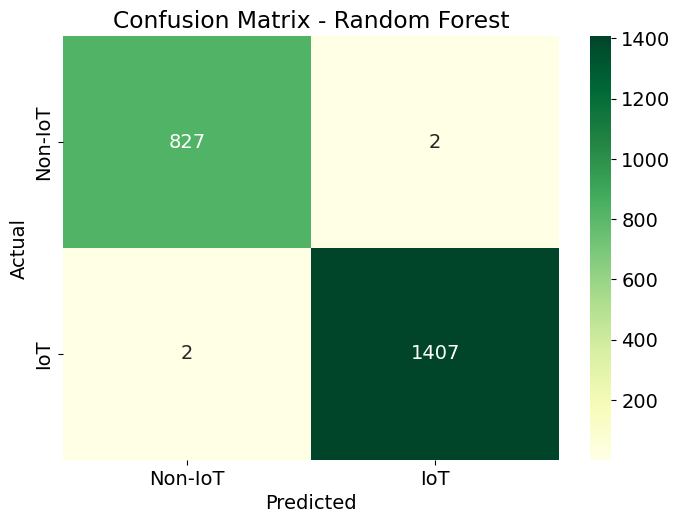

Prediction time: 0.014696359634399414 seconds
Model Accuracy: 99.82%
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       829
           1       1.00      1.00      1.00      1409

    accuracy                           1.00      2238
   macro avg       1.00      1.00      1.00      2238
weighted avg       1.00      1.00      1.00      2238



In [3]:
# Load the dataset
df = pd.read_csv("iot_1000_packet_windows.csv")


features = [
    "total_bytes", "avg_packet_size", "max_packet_size", "min_packet_size",  "tcp_ratio", "unique_dest_ports", "unique_dest_ips"]
X = df[features]
y = df["device_type"]

# Convert labels 
le = LabelEncoder()
y = le.fit_transform(y) 

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

start = time.time()

# Predict and Evaluate

y_pred_RF = rf_model.predict(X_test)

end = time.time()

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_RF)

# Plot it nicely
plt.figure(figsize=(8,5.5))
plt.rcParams['font.size'] = 14 
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn', xticklabels=["Non-IoT", "IoT"], yticklabels=["Non-IoT", "IoT"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

print("Prediction time:", end - start, "seconds")
print(f"Model Accuracy: {accuracy_score(y_test, y_pred_RF):.2%}")
print("Classification Report:\n", classification_report(y_test, y_pred_RF))

This model below is the Naive Bayes classifier. 
The results contain the execution time aswell as a heatmap for the confusion matrix and a classification report.

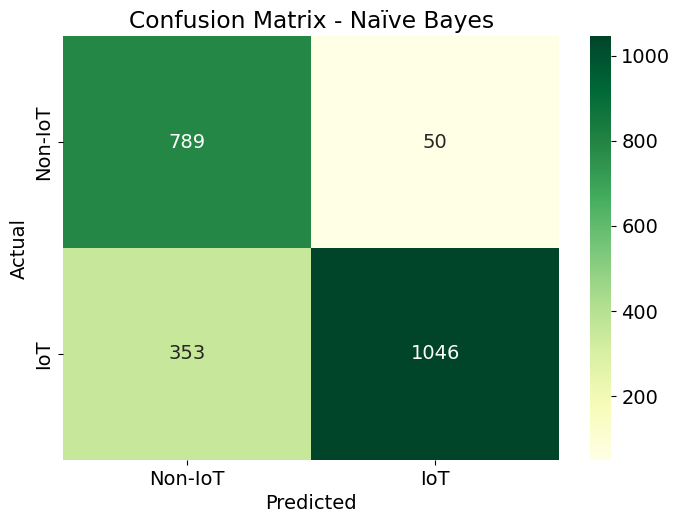

Prediction time: 0.000324249267578125 seconds

Naïve Bayes Model Accuracy: 81.99%
 Classification Report (Naïve Bayes):
               precision    recall  f1-score   support

           0       0.69      0.94      0.80       839
           1       0.95      0.75      0.84      1399

    accuracy                           0.82      2238
   macro avg       0.82      0.84      0.82      2238
weighted avg       0.86      0.82      0.82      2238



In [4]:
# Load dataset
df = pd.read_csv("iot_1000_packet_windows.csv")

# Select features and target variable
features = ["total_bytes", "avg_packet_size", "max_packet_size", "min_packet_size", 
            "tcp_ratio", "unique_dest_ports", "unique_dest_ips"]
X = df[features]
y = df["device_type"]

# Convert labels 
le = LabelEncoder()
y = le.fit_transform(y)  

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Model 
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predict

start = time.time()
y_pred_nb = nb_model.predict(X_test)
end = time.time()

#confusion matrix
cm = confusion_matrix(y_test, y_pred_nb)

# Plot
plt.figure(figsize=(8,5.5))
plt.rcParams['font.size'] = 14 
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn', xticklabels=["Non-IoT", "IoT"], yticklabels=["Non-IoT", "IoT"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naïve Bayes')
plt.show()


print("Prediction time:", end - start, "seconds")
print(f"\nNaïve Bayes Model Accuracy: {accuracy_score(y_test, y_pred_nb):.2%}")
print(" Classification Report (Naïve Bayes):\n", classification_report(y_test, y_pred_nb))


This model below is the KNN classifier. 
The results contain the execution time aswell as a heatmap for the confusion matrix and a classification report.

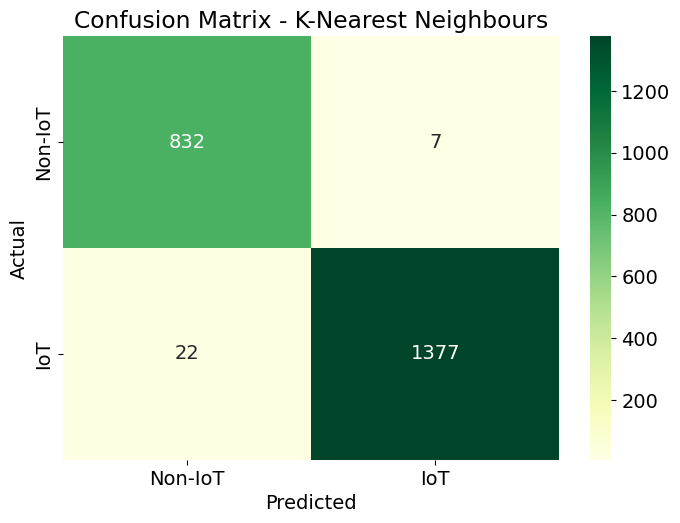

Prediction time: 0.07169198989868164 seconds

🔹 KNN Model Accuracy: 98.70%
🔹 Classification Report (KNN):
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       839
           1       0.99      0.98      0.99      1399

    accuracy                           0.99      2238
   macro avg       0.98      0.99      0.99      2238
weighted avg       0.99      0.99      0.99      2238



In [5]:
# Load dataset
df = pd.read_csv("iot_1000_packet_windows.csv")

# Select features 
features = ["total_bytes", "avg_packet_size", "max_packet_size", "min_packet_size", 
            "tcp_ratio", "unique_dest_ports", "unique_dest_ips"]
X = df[features]
y = df["device_type"]

# Convert labels 
le = LabelEncoder()
y = le.fit_transform(y)  

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Model
knn_model = KNeighborsClassifier(n_neighbors=3) 
knn_model.fit(X_train_scaled, y_train)

# Predict

start = time.time()
y_pred_knn = knn_model.predict(X_test_scaled)
end = time.time()

# confusion matrix
cm = confusion_matrix(y_test, y_pred_knn)

# Plot
plt.figure(figsize=(8,5.5))
plt.rcParams['font.size'] = 14 
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn', xticklabels=["Non-IoT", "IoT"], yticklabels=["Non-IoT", "IoT"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - K-Nearest Neighbours')
plt.show()


print("Prediction time:", end - start, "seconds")
print(f"\n🔹 KNN Model Accuracy: {accuracy_score(y_test, y_pred_knn):.2%}")
print("🔹 Classification Report (KNN):\n", classification_report(y_test, y_pred_knn))


This model below is the Logistic Regression classifier. 
The results contain the execution time aswell as a heatmap for the confusion matrix and a classification report.

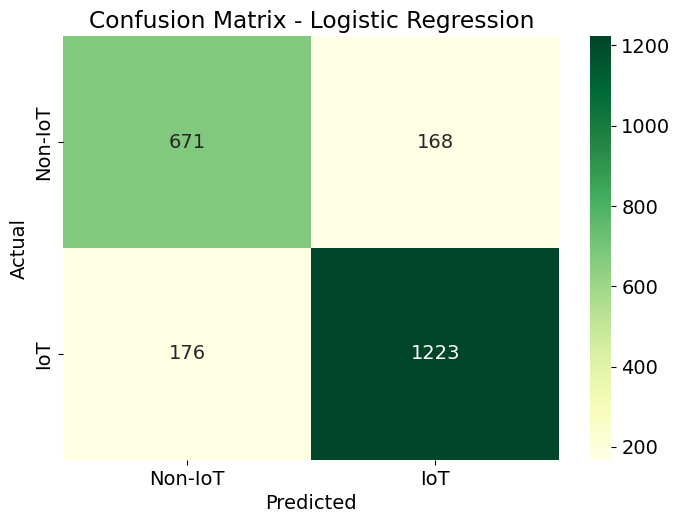

Prediction time: 0.00033974647521972656 seconds

🔹 Logistic Regression Accuracy: 84.63%
🔹 Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           0       0.79      0.80      0.80       839
           1       0.88      0.87      0.88      1399

    accuracy                           0.85      2238
   macro avg       0.84      0.84      0.84      2238
weighted avg       0.85      0.85      0.85      2238



In [6]:
# Load dataset
df = pd.read_csv("iot_1000_packet_windows.csv")

# Select features 
features = ["total_bytes", "avg_packet_size", "max_packet_size", "min_packet_size", 
            "tcp_ratio", "unique_dest_ports", "unique_dest_ips"]
X = df[features]
y = df["device_type"]

# Convert labels 
le = LabelEncoder()
y = le.fit_transform(y)  

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train  Model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# Predict 
start = time.time()
y_pred_log = log_model.predict(X_test_scaled)
end = time.time()

# confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

# Plot
plt.figure(figsize=(8,5.5))
plt.rcParams['font.size'] = 14 
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn', xticklabels=["Non-IoT", "IoT"], yticklabels=["Non-IoT", "IoT"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


print("Prediction time:", end - start, "seconds")
print(f"\n🔹 Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log):.2%}")
print("🔹 Classification Report (Logistic Regression):\n", classification_report(y_test, y_pred_log))

This model below is the SVM classifier. 
The results contain the execution time aswell as a heatmap for the confusion matrix and a classification report.

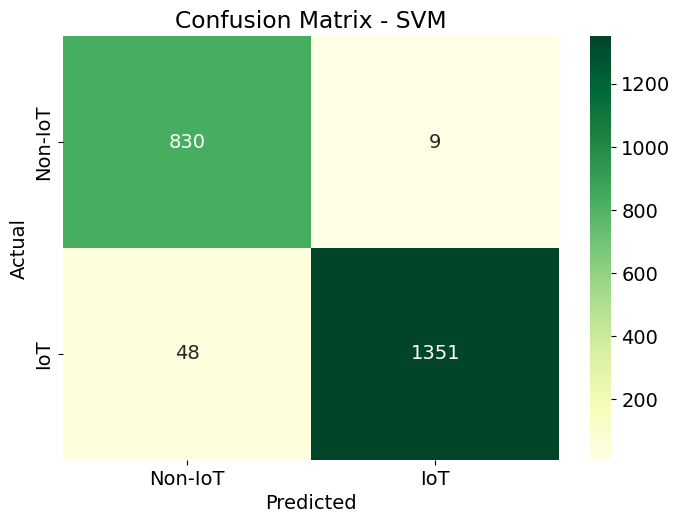

Prediction time: 0.11950898170471191 seconds

🔹 SVM Model Accuracy: 97.45%
🔹 Classification Report (SVM):
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       839
           1       0.99      0.97      0.98      1399

    accuracy                           0.97      2238
   macro avg       0.97      0.98      0.97      2238
weighted avg       0.98      0.97      0.97      2238



In [7]:
# Load dataset
df = pd.read_csv("iot_1000_packet_windows.csv")

# Select features
features = ["total_bytes", "avg_packet_size", "max_packet_size", "min_packet_size", 
            "tcp_ratio", "unique_dest_ports", "unique_dest_ips"]
X = df[features]
y = df["device_type"]

# Convert labels
le = LabelEncoder()
y = le.fit_transform(y)  

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Model
svm_model = SVC(kernel='rbf')  
svm_model.fit(X_train_scaled, y_train)

# Predict 
start = time.time()
y_pred_svm = svm_model.predict(X_test_scaled)
end = time.time()

# confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plot
plt.figure(figsize=(8,5.5))
plt.rcParams['font.size'] = 14 
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn', xticklabels=["Non-IoT", "IoT"], yticklabels=["Non-IoT", "IoT"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.show()


print("Prediction time:", end - start, "seconds")

print(f"\n🔹 SVM Model Accuracy: {accuracy_score(y_test, y_pred_svm):.2%}")

print("🔹 Classification Report (SVM):\n", classification_report(y_test, y_pred_svm))